# KTP Associate Pre-Interview Data Analysis Exercise

## Question 3: What factors appear to influence product degradation?

This notebook investigates which experimental variables appear most associated with changes in product quality over time, using both visual and simple quantitative evidence.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for metric_name, pair_cols in {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}.items():
    df[metric_name + '_mean'] = df[pair_cols].mean(axis=1)
df['is_control'] = df['exposure_days'].eq(0)
control_map = df.loc[df['is_control']].set_index('lot')[['assay_mean','imp092_mean','imp123_mean']].to_dict('index')
analysis_df = df.loc[~df['is_control']].copy()
for col_name in ['temp_c', 'rh', 'exposure_days']:
    analysis_df[col_name] = pd.to_numeric(analysis_df[col_name], errors='coerce')
analysis_df['assay_loss'] = analysis_df.apply(lambda row: control_map[row['lot']]['assay_mean'] - row['assay_mean'], axis=1)
analysis_df['imp092_gain'] = analysis_df.apply(lambda row: row['imp092_mean'] - control_map[row['lot']]['imp092_mean'], axis=1)
analysis_df['imp123_gain'] = analysis_df.apply(lambda row: row['imp123_mean'] - control_map[row['lot']]['imp123_mean'], axis=1)
analysis_df.head()


,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh,analyst,assay_s1,assay_s2,...,imp123_s1,imp123_s2,lot,assay_mean,imp092_mean,imp123_mean,is_control,assay_loss,imp092_gain,imp123_gain
0,2025-12-18,2026-01-08,0,21,Oven 2,70,11,RG,8.185,8.119,...,0.074,0.074,A014,8.1520,0.2850,0.074,False,4.6470,0.2850,-0.001
1,2025-12-18,2026-01-08,0,21,Oven 4,65,25,SS,11.184,10.702,...,0.134,0.136,A014,10.9430,0.2305,0.135,False,1.8560,0.2305,0.060
2,2025-12-18,2026-01-08,0,21,Oven 1,50,64,SS,12.100,12.238,...,0.191,0.189,A014,12.1690,0.2220,0.190,False,0.6300,0.2220,0.115
3,2025-12-18,2026-01-08,0,21,Oven 3,60,80,CM,11.518,11.095,...,0.167,0.171,A014,11.3065,0.6620,0.169,False,1.4925,0.6620,0.094
4,2025-12-18,2026-01-08,0,21,Oven 3,60,42,CM,11.813,11.294,...,0.176,0.176,A014,11.5535,0.5340,0.176,False,1.2455,0.5340,0.101


In [2]:
summary_rows = []
for response_name in ['assay_loss', 'imp092_gain', 'imp123_gain']:
    fit_reg = LinearRegression()
    fit_reg.fit(analysis_df[['exposure_days', 'temp_c', 'rh']], analysis_df[response_name])
    pred_vals = fit_reg.predict(analysis_df[['exposure_days', 'temp_c', 'rh']])
    summary_rows.append({'response': response_name, 'r2': round(r2_score(analysis_df[response_name], pred_vals), 3), 'coef_exposure_days': round(fit_reg.coef_[0], 4), 'coef_temp_c': round(fit_reg.coef_[1], 4), 'coef_rh': round(fit_reg.coef_[2], 4)})
model_summary_df = pd.DataFrame(summary_rows)
corr_table = analysis_df[['exposure_days','temp_c','rh','assay_loss','imp092_gain','imp123_gain']].corr().round(3)
model_summary_df
corr_table


,exposure_days,temp_c,rh,assay_loss,imp092_gain,imp123_gain
exposure_days,1.000,-0.358,-0.233,0.436,0.203,-0.868
temp_c,-0.358,1.000,-0.274,0.551,0.414,0.362
rh,-0.233,-0.274,1.000,-0.335,0.052,0.368
assay_loss,0.436,0.551,-0.335,1.000,0.368,-0.437
imp092_gain,0.203,0.414,0.052,0.368,1.000,-0.022
imp123_gain,-0.868,0.362,0.368,-0.437,-0.022,1.000


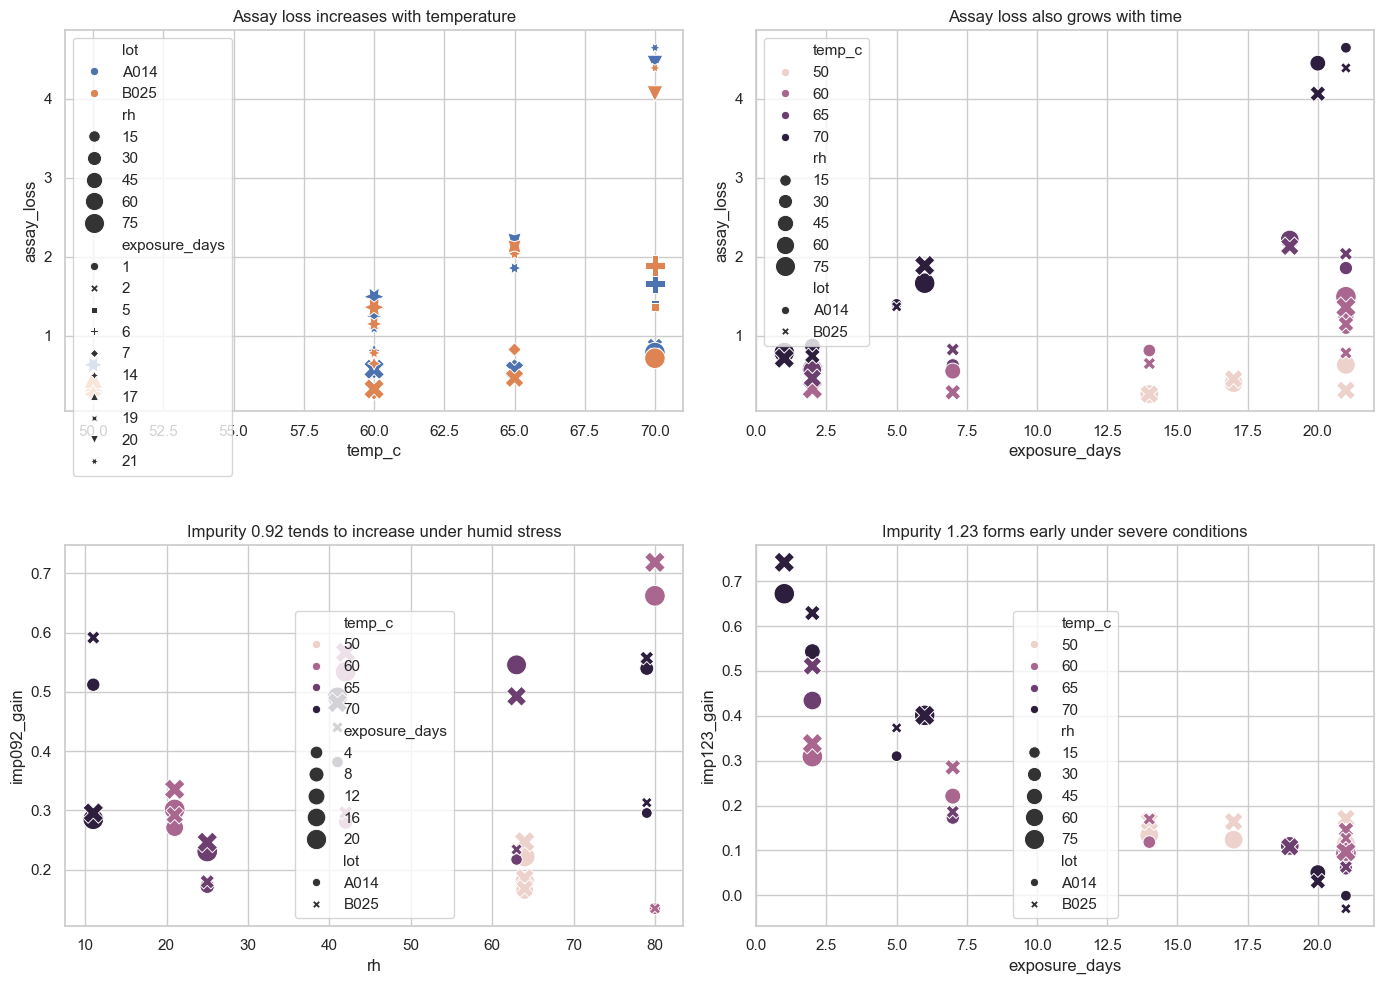

In [3]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.scatterplot(data=analysis_df, x='temp_c', y='assay_loss', hue='lot', style='exposure_days', size='rh', sizes=(60, 220), ax=axes[0,0])
axes[0,0].set_title('Assay loss increases with temperature')
sns.scatterplot(data=analysis_df, x='exposure_days', y='assay_loss', hue='temp_c', style='lot', size='rh', sizes=(60, 220), ax=axes[0,1])
axes[0,1].set_title('Assay loss also grows with time')
sns.scatterplot(data=analysis_df, x='rh', y='imp092_gain', hue='temp_c', style='lot', size='exposure_days', sizes=(60, 220), ax=axes[1,0])
axes[1,0].set_title('Impurity 0.92 tends to increase under humid stress')
sns.scatterplot(data=analysis_df, x='exposure_days', y='imp123_gain', hue='temp_c', style='lot', size='rh', sizes=(60, 220), ax=axes[1,1])
axes[1,1].set_title('Impurity 1.23 forms early under severe conditions')
plt.tight_layout()
plt.show()


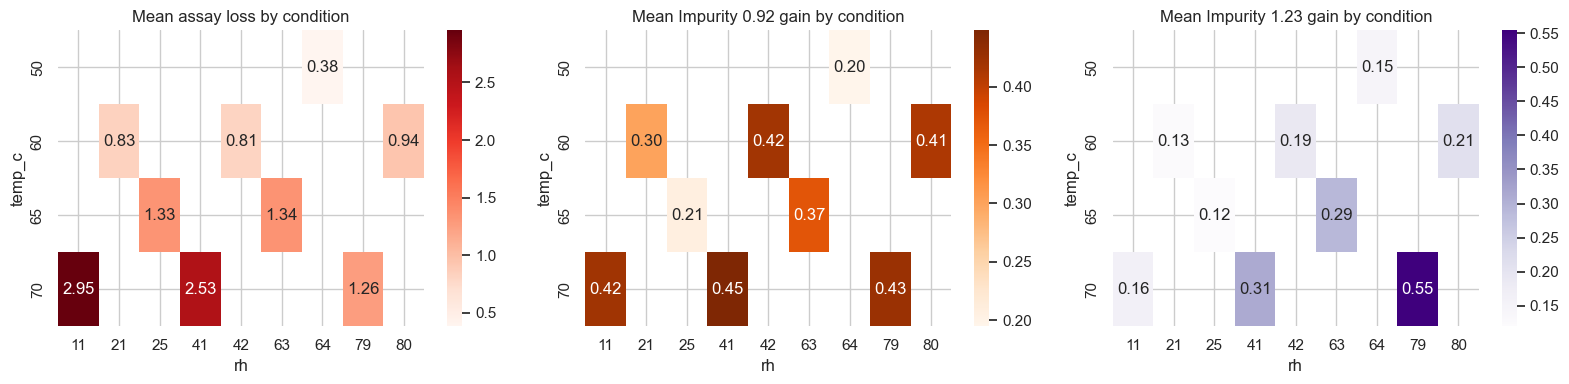

In [4]:
condition_summary_df = analysis_df.groupby(['temp_c', 'rh']).agg(rows=('lot', 'size'), assay_loss_mean=('assay_loss', 'mean'), imp092_gain_mean=('imp092_gain', 'mean'), imp123_gain_mean=('imp123_gain', 'mean')).reset_index().round(3)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(condition_summary_df.pivot(index='temp_c', columns='rh', values='assay_loss_mean'), annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
axes[0].set_title('Mean assay loss by condition')
sns.heatmap(condition_summary_df.pivot(index='temp_c', columns='rh', values='imp092_gain_mean'), annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Mean Impurity 0.92 gain by condition')
sns.heatmap(condition_summary_df.pivot(index='temp_c', columns='rh', values='imp123_gain_mean'), annot=True, fmt='.2f', cmap='Purples', ax=axes[2])
axes[2].set_title('Mean Impurity 1.23 gain by condition')
plt.tight_layout()
plt.show()


## Interpretation

The clearest factor associated with degradation is temperature. As temperature increases, assay loss becomes larger and impurity formation generally becomes more pronounced. This pattern is visible in the scatter plots and is also reflected in the positive temperature coefficients for impurity gain and the negative temperature effect on assay.

Exposure duration is also important. Longer stress periods are associated with lower assay and higher Impurity RRT 0.92. The effect on Impurity RRT 1.23 appears different: it often rises quickly at short times under severe conditions, suggesting early formation rather than steady long-term accumulation.

Humidity appears to play a secondary but still meaningful role, especially for Impurity RRT 0.92 and Impurity RRT 1.23. The heatmaps suggest that humid conditions can amplify degradation, although the effect is harder to isolate cleanly because the dataset is small and not fully balanced across factor combinations.

The main limitation is that the variables are not fully orthogonal and the study includes only one lot per formulation. That means the coefficients should be interpreted as directional evidence rather than precise causal estimates. The patterns are still useful for development decisions, but they would need confirmation in a larger, better-balanced follow-up study.
